In [15]:
import os
import random
import zipfile
from io import BytesIO
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from sklearn.model_selection import train_test_split
from huggingface_hub import HfFileSystem

HF_DATASET = "Jogitha/Animal_Image_Classification_Dataset"
ZIP_URL    = f"datasets/{HF_DATASET}/cats_dogs_snakes.zip"
WORK_DIR   = Path("animal")
WORK_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = WORK_DIR
IMG_SIZE   = (64, 64)
SEED       = 42
IMG_EXTS   = {".jpg", ".jpeg"}

random.seed(SEED)
np.random.seed(SEED)

## 1. Find all images and their class labels
The class label is taken from the name of the folder each image is in (e.g. `.../cats/img001.jpg` → `cats`).
Check the printed counts: they should match the dataset description.

In [16]:
# Read the zip from Hugging Face into memory (nothing saved to disk)
with HfFileSystem().open(ZIP_URL, "rb") as fh:
    zf = zipfile.ZipFile(BytesIO(fh.read()))

def load_image(path):
    """Open one image from the in-memory zip."""
    return Image.open(BytesIO(zf.read(path))).convert("RGB")

paths, labels = [], []
for name in sorted(zf.namelist()):
    if Path(name).suffix.lower() in IMG_EXTS and "__MACOSX" not in name:
        paths.append(name)
        labels.append(Path(name).parent.name.lower())   # folder name = class

classes = sorted(set(labels))
print(f"Found {len(paths)} images in {len(classes)} classes:")
for c, n in sorted(Counter(labels).items()):
    print(f"  {c:<20} {n}")

Found 3000 images in 3 classes:
  cats                 1000
  dogs                 1000
  snakes               1000


## 2. Downscale ALL images to 64 × 64
- `ImageOps.fit` centre-crops to a square first (so non-square images are not stretched), then resizes.
- `Image.LANCZOS` applies an **anti-aliasing (low-pass) filter**, so no extra filter is needed.
- Saved as PNG to avoid adding JPEG compression artefacts.
- All downscaled images go to `data_64/all/<class>/`.

In [17]:
import shutil

shutil.rmtree(OUTPUT_DIR, ignore_errors=True)   # start clean, so re-running never leaves old/duplicate files
ALL_DIR = OUTPUT_DIR

def downscale(src, dst):
    img = Image.open(BytesIO(zf.read(src)))  
    img = ImageOps.exif_transpose(img).convert("RGB")       # fix rotation, force 3 channels
    img = ImageOps.fit(img, IMG_SIZE, method=Image.LANCZOS)  # crop to square + anti-aliased resize
    img.save(dst)

small_paths = []                                  # paths of the 64x64 images, same order as `labels`
for i, (src, cls) in enumerate(zip(paths, labels)):
    out_dir = ALL_DIR / cls
    out_dir.mkdir(parents=True, exist_ok=True)
    dst = out_dir / f"{cls}_{i:05d}.png"
    downscale(src, dst)
    small_paths.append(dst)

print(f"Downscaled {len(small_paths)} images to {IMG_SIZE[0]}x{IMG_SIZE[1]} -> {ALL_DIR}")

Downscaled 3000 images to 64x64 -> animal


## 3. Split the downscaled images: 70% train, 15% validation, 15% test
`stratify` keeps the same class proportions in every split. The 64 × 64 images are then copied into
`data_64/train`, `data_64/val` and `data_64/test`, one folder per class.

In [18]:
train_p, temp_p, train_y, temp_y = train_test_split(
    small_paths, labels, test_size=0.30, stratify=labels, random_state=SEED)
val_p, test_p, val_y, test_y = train_test_split(
    temp_p, temp_y, test_size=0.50, stratify=temp_y, random_state=SEED)

splits = {"train": (train_p, train_y), "val": (val_p, val_y), "test": (test_p, test_y)}
for name, (p_list, y_list) in splits.items():
    for src, cls in zip(p_list, y_list):
        out_dir = OUTPUT_DIR / name / cls
        out_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy(src, out_dir / src.name)
    print(f"{name:<5}: {len(p_list):>6} images  {dict(sorted(Counter(y_list).items()))}")

train:   2100 images  {'cats': 700, 'dogs': 700, 'snakes': 700}
val  :    450 images  {'cats': 150, 'dogs': 150, 'snakes': 150}
test :    450 images  {'cats': 150, 'dogs': 150, 'snakes': 150}


## 4. Before / after figure 

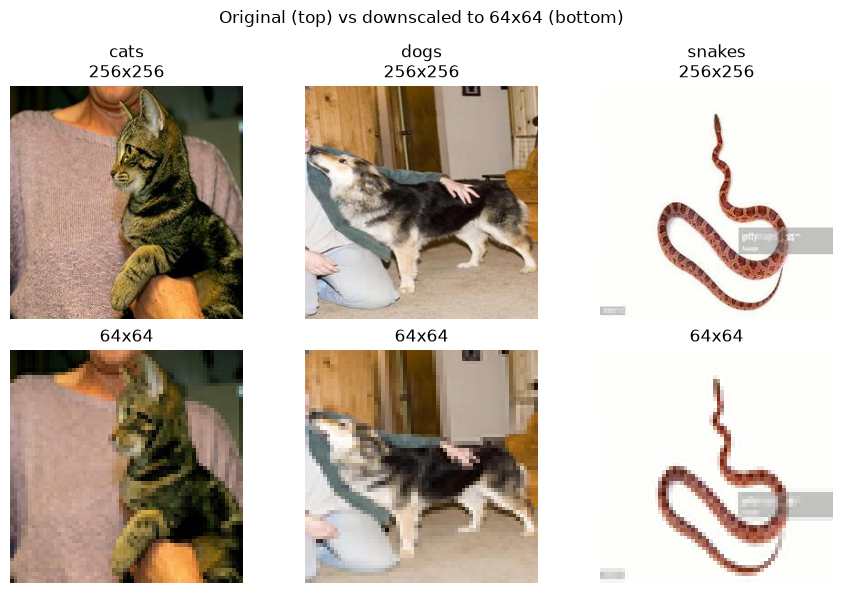

In [20]:
n = min(5, len(classes))
fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
axes = np.array(axes).reshape(2, -1)
for j, cls in enumerate(classes[:n]):
    i = labels.index(cls)                                                  # first image of this class
    orig = ImageOps.exif_transpose(Image.open(BytesIO(zf.read(paths[i])))).convert("RGB")   # original (from zip)     # original
    small = Image.open(small_paths[i])                                      # its saved 64x64 version
    axes[0, j].imshow(orig);  axes[0, j].set_title(f"{cls}\n{orig.size[0]}x{orig.size[1]}")
    axes[1, j].imshow(small); axes[1, j].set_title(f"64x64")
    axes[0, j].axis("off");   axes[1, j].axis("off")
plt.suptitle("Original (top) vs downscaled to 64x64 (bottom)")
plt.tight_layout()
plt.savefig(WORK_DIR / "before_after.png", dpi=150)
plt.show()

## 5. Load the 64 × 64 data for training
Every model (A, B, MobileNet, EfficientNet) should load from these same folders, so they all use the same split.

In [21]:
# TensorFlow / Keras
import tensorflow as tf

BATCH = 32
train_ds = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR / "train", image_size=IMG_SIZE, batch_size=BATCH, seed=SEED, shuffle=True)
val_ds = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR / "val", image_size=IMG_SIZE, batch_size=BATCH, shuffle=False)
test_ds = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR / "test", image_size=IMG_SIZE, batch_size=BATCH, shuffle=False)

print("Classes:", train_ds.class_names)

# Scale pixels to 0-1 for the custom models (A and B).
# For MobileNetV2 / EfficientNet use their own preprocess_input instead.
normalize = tf.keras.layers.Rescaling(1.0 / 255)
train_ds_n = train_ds.map(lambda x, y: (normalize(x), y))
val_ds_n   = val_ds.map(lambda x, y: (normalize(x), y))
test_ds_n  = test_ds.map(lambda x, y: (normalize(x), y))

Found 2100 files belonging to 3 classes.
Found 450 files belonging to 3 classes.
Found 450 files belonging to 3 classes.
Classes: ['cats', 'dogs', 'snakes']


# Model A – Standard CNN
Four blocks of **Conv2D (3×3) → ReLU → MaxPooling (2×2)**, with filters doubling 32 → 64 → 128 → 256,
then **Global Average Pooling → Dense(128) → Dropout → Dense(classes, softmax)**.

| Layer | Output shape | Kernel / units | Trainable params |
|---|---|---|---|
| Input | 64×64×3 | – | 0 |
| Conv2D + ReLU | 64×64×32 | 3×3, 32 filters | 3·3·3·32 + 32 = 896 |
| MaxPool | 32×32×32 | 2×2 | 0 |
| Conv2D + ReLU | 32×32×64 | 3×3, 64 filters | 3·3·32·64 + 64 = 18,496 |
| MaxPool | 16×16×64 | 2×2 | 0 |
| Conv2D + ReLU | 16×16×128 | 3×3, 128 filters | 3·3·64·128 + 128 = 73,856 |
| MaxPool | 8×8×128 | 2×2 | 0 |
| Conv2D + ReLU | 8×8×256 | 3×3, 256 filters | 3·3·128·256 + 256 = 295,168 |
| MaxPool | 4×4×256 | 2×2 | 0 |
| GlobalAvgPool | 256 | – | 0 |
| Dense + ReLU | 128 | 128 units | 256·128 + 128 = 32,896 |
| Dropout | 128 | rate 0.3 | 0 |
| Dense + Softmax | C | C units | 128·C + C (= 387 for C = 3) |
| **Total (C = 3)** | | | **421,699** |

Conv params = K·K·C_in·C_out + C_out (bias). Dense params = inputs·units + units.

In [22]:
from tensorflow.keras import layers, models
import time

tf.keras.utils.set_random_seed(SEED)        # reproducible weight initialisation
NUM_CLASSES = len(train_ds.class_names)
AUTOTUNE = tf.data.AUTOTUNE

# Keep decoded images in memory and prepare the next batch while the GPU trains (faster epochs).
# Training data: cache single images, then re-shuffle every epoch and re-batch.
train_ds_n = (train_ds_n.unbatch().cache()
              .shuffle(2000, seed=SEED, reshuffle_each_iteration=True)
              .batch(BATCH).prefetch(AUTOTUNE))
val_ds_n   = val_ds_n.cache().prefetch(AUTOTUNE)
test_ds_n  = test_ds_n.cache().prefetch(AUTOTUNE)

def build_model_a(input_shape=(64, 64, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, kernel_size=3, padding="same", activation="relu")(x)
        x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inputs, outputs, name="Model_A_StandardCNN")

model_a = build_model_a()
model_a.summary()

Model: "Model_A_StandardCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,699 (1.61 MB)

 Trainable params: 421,699 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## Check the parameter count by hand and count MACs (multiply-accumulate operations)

In [23]:
def conv_params(k, c_in, c_out):  return k * k * c_in * c_out + c_out
def dense_params(n_in, n_out):     return n_in * n_out + n_out
def conv_macs(h, w, k, c_in, c_out): return h * w * k * k * c_in * c_out   # 'same' padding, stride 1

rows = []   # (layer, params, MACs)
c_in, size = 3, 64
for f in [32, 64, 128, 256]:
    rows.append((f"Conv2D 3x3, {f} ({size}x{size})", conv_params(3, c_in, f), conv_macs(size, size, 3, c_in, f)))
    c_in, size = f, size // 2
rows.append(("Dense 128", dense_params(256, 128), 256 * 128))
rows.append((f"Dense {NUM_CLASSES}", dense_params(128, NUM_CLASSES), 128 * NUM_CLASSES))

print(f"{'Layer':<30}{'Params':>12}{'MACs':>16}")
for name, p, m in rows:
    print(f"{name:<30}{p:>12,}{m:>16,}")
total_p = sum(r[1] for r in rows); total_m = sum(r[2] for r in rows)
print(f"{'TOTAL':<30}{total_p:>12,}{total_m:>16,}")
print("Keras count:", f"{model_a.count_params():,}", "| match:", total_p == model_a.count_params())

Layer                               Params            MACs
Conv2D 3x3, 32 (64x64)                 896       3,538,944
Conv2D 3x3, 64 (32x32)              18,496      18,874,368
Conv2D 3x3, 128 (16x16)             73,856      18,874,368
Conv2D 3x3, 256 (8x8)              295,168      18,874,368
Dense 128                           32,896          32,768
Dense 3                                387             384
TOTAL                              421,699      60,195,200
Keras count: 421,699 | match: True


## Compile and train (20 epochs)
Adam with learning rate 0.001. Labels are integers (0, 1, 2…), so the loss is `sparse_categorical_crossentropy`.
A small callback records the time of every epoch for the comparison table.

In [24]:
class EpochTimer(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None): self.times = []
    def on_epoch_begin(self, epoch, logs=None): self._t = time.time()
    def on_epoch_end(self, epoch, logs=None): self.times.append(time.time() - self._t)

EPOCHS = 20
model_a.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])

timer_a = EpochTimer()
history_a = model_a.fit(train_ds_n, validation_data=val_ds_n, epochs=EPOCHS, callbacks=[timer_a])

# first epoch includes one-off setup (graph building, caching), so report the mean of the rest
print(f"Average time per epoch (epochs 2-{EPOCHS}): {np.mean(timer_a.times[1:]):.2f} s")

Epoch 1/20
     65/Unknown 4s 28ms/step - accuracy: 0.3424 - loss: 1.0823

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.3444 - loss: 1.0813 - val_accuracy: 0.5778 - val_loss: 0.9072
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.4972 - loss: 0.9411 - val_accuracy: 0.3867 - val_loss: 1.0508
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4721 - loss: 0.9762 - val_accuracy: 0.6044 - val_loss: 0.8325
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.5409 - loss: 0.8851 - val_accuracy: 0.5778 - val_loss: 0.8399
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.5777 - loss: 0.8118 - val_accuracy: 0.6356 - val_loss: 0.7680
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.6122 - loss: 0.7883 - val_accuracy: 0.6356 - val_loss: 0.7563
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.6429 - loss: 0.7639 - val_accuracy: 0.6533 - val_loss: 0.7348
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.6662 - loss: 0.7350 - val_accuracy: 0.5933 - val_loss: 0.

## Training / validation curves

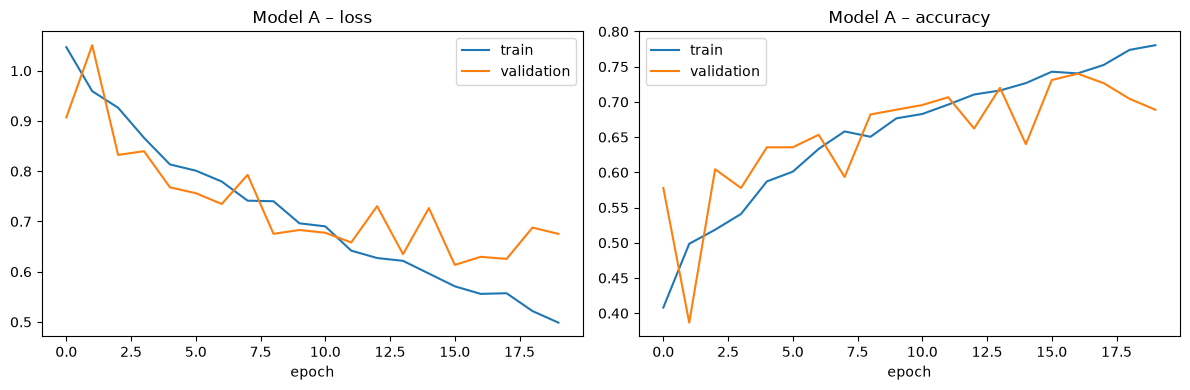

In [25]:
def plot_history(history, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history.history["loss"], label="train");     ax[0].plot(history.history["val_loss"], label="validation")
    ax[0].set_title(f"{title} – loss");     ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(history.history["accuracy"], label="train"); ax[1].plot(history.history["val_accuracy"], label="validation")
    ax[1].set_title(f"{title} – accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout()
    plt.savefig(WORK_DIR / f"{title.replace(' ', '_')}_curves.png", dpi=150)
    plt.show()

plot_history(history_a, "Model A")

## Test-set evaluation: accuracy, confusion matrix, precision, recall

Model A test accuracy: 0.7044

              precision    recall  f1-score   support

        cats     0.6000    0.8600    0.7068       150
        dogs     0.8644    0.3400    0.4880       150
      snakes     0.7784    0.9133    0.8405       150

    accuracy                         0.7044       450
   macro avg     0.7476    0.7044    0.6785       450
weighted avg     0.7476    0.7044    0.6785       450



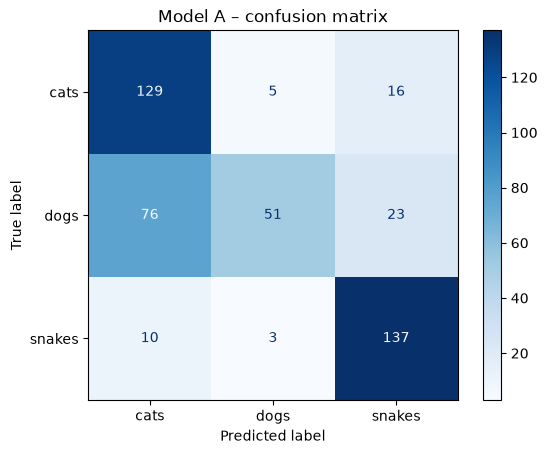

In [26]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

def evaluate(model, ds, title):
    y_true = np.concatenate([y.numpy() for _, y in ds])
    y_pred = np.argmax(model.predict(ds, verbose=0), axis=1)
    names = train_ds.class_names
    acc = np.mean(y_true == y_pred)
    print(f"{title} test accuracy: {acc:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=names, digits=4, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=names).plot(cmap="Blues", values_format="d")
    plt.title(f"{title} – confusion matrix")
    plt.savefig(WORK_DIR / f"{title.replace(' ', '_')}_confusion.png", dpi=150, bbox_inches="tight")
    plt.show()
    return acc

test_acc_a = evaluate(model_a, test_ds_n, "Model A")

## Model size on disk
A trained model's `.keras` file also stores the Adam optimizer state (about 2 extra copies of every weight), which is
not deployed to a device. So the size is measured on a clean copy without the optimizer – the fair "model size" for
the comparison table.

In [27]:
def deploy_size_kb(model, build_fn, path):
    """Save an uncompiled copy (weights only, no optimizer state) and return its size in KB."""
    clean = build_fn()
    clean.set_weights(model.get_weights())
    clean.save(path)
    return os.path.getsize(path) / 1024

model_a.save(WORK_DIR / "model_a_full.keras")   # full model incl. optimizer, to resume training later
size_a_kb = deploy_size_kb(model_a, build_model_a, WORK_DIR / "model_a.keras")

print(f"Model A: {model_a.count_params():,} params")
print(f"  weights file on disk : {size_a_kb:.1f} KB")
print(f"  theoretical float32  : {model_a.count_params() * 4 / 1024:.1f} KB  (4 bytes per weight)")
print(f"  if quantised to int8 : {model_a.count_params() / 1024:.1f} KB  (1 byte per weight)")
print(f"  time per epoch       : {np.mean(timer_a.times[1:]):.2f} s")
print(f"  test accuracy        : {test_acc_a:.4f}")

Model A: 421,699 params
  weights file on disk : 1693.9 KB
  theoretical float32  : 1647.3 KB  (4 bytes per weight)
  if quantised to int8 : 411.8 KB  (1 byte per weight)
  time per epoch       : 4.19 s
  test accuracy        : 0.7044
